### **🪖 Demo Deteksi Helm (Notebook)**

Notebook ini menggantikan fungsi aplikasi Streamlit (alternatif demo).  
Kamu bisa meng-upload gambar, mengatur confidence threshold, dan melihat hasil deteksi secara langsung.

**Cara pakai:**
1. Jalankan semua sel di atas (kernel harus sudah terhubung).
2. Upload gambar via tombol "Pilih gambar".
3. Atur threshold confidence.
4. Klik "Deteksi" untuk melihat hasil.
5. Hasil akan muncul di bawah (gambar asli vs anotasi, ringkasan deteksi).

In [25]:
# 1. IMPORT & LOAD MODEL
import io
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, Image as IPImage
import ipywidgets as widgets
from ultralytics import YOLO
import time
import glob

MODEL_PATH = os.path.join("..", "models", "best.pt")
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = "helmet_detection_runs/yolov8n_helmet/weights/best.pt"

model = YOLO(MODEL_PATH)
print("Model loaded.")

Model loaded.


In [26]:
# 2. FUNGSI DETEKSI
def detect_from_bytes(image_bytes, conf=0.5):
    nparr = np.frombuffer(image_bytes, np.uint8)
    img_bgr = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError("Gambar tidak valid atau corrupt.")
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Simpan sementara
    temp_path = "temp_demo.jpg"
    cv2.imwrite(temp_path, img_bgr)
    
    results = model(temp_path, conf=conf)
    os.remove(temp_path)
    
    result = results[0]
    annotated_bgr = result.plot()
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    
    return img_rgb, annotated_rgb, result.boxes


In [27]:
# 3. BUAT WIDGET
# Upload gambar
upload_widget = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='Upload Gambar'
)

conf_slider = widgets.FloatSlider(
    min=0.1, max=0.9, step=0.05, value=0.5,
    description='Confidence:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

button = widgets.Button(
    description='Deteksi',
    button_style='primary',
    layout=widgets.Layout(width='150px')
)

output = widgets.Output()

ui = widgets.VBox([
    widgets.HBox([upload_widget, conf_slider]),
    button,
    output
])
display(ui)

In [31]:
# 4. FUNGSI TAMPIL BEFORE-AFTER
def show_before_after(img_orig, img_annot, save_path=None):
    """Tampilkan dua gambar berdampingan: Before (asli) dan After (hasil deteksi)"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Gambar asli
    ax1.imshow(img_orig)
    ax1.set_title("📷 BEFORE (Gambar Asli)", fontsize=16, fontweight='bold', pad=15)
    ax1.axis('off')
    
    # Gambar hasil deteksi
    ax2.imshow(img_annot)
    ax2.set_title("✅ AFTER (Hasil Deteksi)", fontsize=16, fontweight='bold', pad=15)
    ax2.axis('off')
    
    # Tambahkan border atau garis pembatas (opsional)
    plt.tight_layout()
    plt.show()
    
    # Tampilkan juga gambar hasil dalam ukuran besar jika mau
    if save_path and os.path.exists(save_path):
        print("📁 Gambar hasil juga disimpan di:", save_path)
        display(IPImage(filename=save_path, width=800))

In [32]:
# 5. CALLBACK TOMBOL
def on_button_clicked(b):
    with output:
        clear_output(wait=True)
        
        if not upload_widget.value:
            print("⚠️ Silakan upload gambar terlebih dahulu.")
            return
        
        file_info = upload_widget.value[0]
        file_name = file_info['name']
        file_content = file_info['content']
        conf = conf_slider.value
        
        print(f"🔄 Memproses {file_name} dengan confidence {conf:.2f}...")
        
        try:
            img_orig, img_annot, boxes = detect_from_bytes(file_content, conf)
        except Exception as e:
            print(f"❌ Error: {e}")
            return
        
        # Simpan hasil ke folder ../img/
        os.makedirs("../img/", exist_ok=True)
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        save_path = os.path.join("../img/", f"result_demo_{timestamp}.png")
        cv2.imwrite(save_path, cv2.cvtColor(img_annot, cv2.COLOR_RGB2BGR))
        
        # Tampilkan Before-After
        show_before_after(img_orig, img_annot, save_path)
        
        # Ringkasan deteksi
        if boxes is not None and len(boxes.cls) > 0:
            total = len(boxes.cls)
            class_ids = boxes.cls.int().tolist()
            confs = boxes.conf.float().tolist()
            with_helmet = class_ids.count(0)
            without_helmet = class_ids.count(1)
            
            print(f"\n📊 RINGKASAN DETEKSI")
            print("-" * 40)
            print(f"✅ Total pengendara terdeteksi: {total}")
            print(f"   🪖 Dengan helm: {with_helmet}")
            print(f"   ❌ Tanpa helm: {without_helmet}")
            print("\n🎯 Confidence per objek:")
            for i, (cls_id, conf_val) in enumerate(zip(class_ids, confs), 1):
                cls_name = "Dengan Helm" if cls_id == 0 else "Tanpa Helm"
                print(f"   {i}. {cls_name}: {conf_val:.2f}")
        else:
            print("\n⚠️ Tidak ada objek terdeteksi. Coba turunkan confidence threshold.")

button.on_click(on_button_clicked)


📸 GALERI HASIL DETEKSI SEBELUMNYA
----------------------------------------
Ditemukan 1 gambar hasil deteksi:


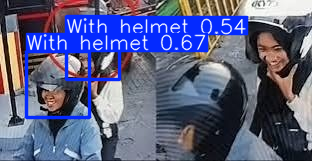

   📁 result_demo_20260618_081308.png



In [33]:
# 6. GALERI HASIL SEBELUMNYA
demo_dir = "../img/"
image_files = sorted(glob.glob(os.path.join(demo_dir, "result_demo_*.png")), reverse=True)

print("\n📸 GALERI HASIL DETEKSI SEBELUMNYA")
print("-" * 40)
if image_files:
    print(f"Ditemukan {len(image_files)} gambar hasil deteksi:")
    for img_path in image_files[:5]:  # tampilkan 5 terbaru
        display(IPImage(filename=img_path, width=700))
        print(f"   📁 {os.path.basename(img_path)}\n")
    if len(image_files) > 5:
        print(f"... dan {len(image_files)-5} gambar lainnya.")
else:
    print("Belum ada gambar hasil deteksi. Jalankan deteksi terlebih dahulu.")